# Description of this study
* Pyrometer emits a spot light visible within the spectral range of the XIMEA
* The objective of this study is to find the area within the FoV of the two devices where the pyrometer was aiming at.


# Imports

In [1]:
import os
import cv2
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime
import time
from pathlib import Path


import scienceplots
plt.style.use(['science', 'notebook', 'grid'])


from TherMIFASOL.core.variables.GlobalVariables import (
    LINES_CRED, COLUMNS_CRED,
)
from TherMIFASOL.core.data_processing.XIMEA_functions import (
    load_splitted_channels_nir,
)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [2]:
PATH_DATA = "/media/dolle/Extreme SSD/DATA_MIFASOL/"
# Work path project
try:
    BASE_DIR = Path(__file__).resolve().parents[3]
except NameError:
    BASE_DIR = Path().resolve().parents[3]


# Path to data
#-------------------
data_path = os.path.join(
    PATH_DATA, "experiences/7 AddMultiSpectral/pyrometer_relative_position/"
)


# Homographic matrix
#-------------------
H_matrix_path = os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/homographic_matrix/")


# Calibration tables
#-------------------
##   CRED:
array_nuc = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/NUC/NUC_2pts_Temp550_WithNeutralDensity.npy"
        )
    )
array_calibration = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/FLUX/FLUX_IT40_deg1_NUC2.npy"
        )
    )
## XIMEA:
XIMEA_NUC_table = np.load(
    os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/XIMEA_TRAVAIL_EMMANUEL/nuc_NUC_LURPA.npy")
)
# Flux: IT3 --> 102 µs"
XIMEA_flux_table_Poly1 = np.load(
    os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/XIMEA_TRAVAIL_EMMANUEL/table_flux_IT3_afterNUC1.npy")
)  ## Poly1: Linear flux/DL relationship ---> extrapolation
XIMEA_flux_table_Poly5 = np.load(
    os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/XIMEA_TRAVAIL_EMMANUEL/table_flux_IT3_afterNUC5.npy")
)  ## Poly5: flux/DL relationship ---> interpolation
Low_limit_for_switch = np.load(
    os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/XIMEA_TRAVAIL_EMMANUEL/LimiteBASSE_DL.npy")
)  # Limit for switching to interpolate side to extrapolate side


# Saving path
#------------
saving_path = os.path.join(BASE_DIR, "results/AddMultiSpectral/pyrometer_relative_position/")

# Preliminary work

## Homographic matrix

In [3]:
with open(f'{H_matrix_path}/H_matrix.pkl', 'rb') as f:
    matrice_H = pickle.load(f)

# Local Functions

In [4]:
def get_metadata_CRED(recorded_time_path:str):
    tim_python_NIR = np.loadtxt(f'{recorded_time_path}')
    return tim_python_NIR

In [5]:
def get_metadata_XIQ(metadata_path:str, delay:float):
    
    metadata_NIR=pd.read_csv(metadata_path, encoding='unicode_escape', sep=',')
    tim_python_NIR=np.asarray(metadata_NIR['t(s)'])
    exposure=np.asarray(metadata_NIR['ExposureTime']).mean()
    id_im_NIR = np.asarray(metadata_NIR['ImageUniqueID'])

    absolute_time = np.asarray([
        time.mktime(datetime.strptime(t, "%Y:%m:%d %H:%M:%S").timetuple()) \
             for t in metadata_NIR['DateTimeOriginal']
    ]) + np.asarray(metadata_NIR['SubsecTimeOriginal']) + delay

    return tim_python_NIR, id_im_NIR, absolute_time, exposure

# Main Study

In [6]:
# CRED metadata
metadata_CRED=pd.read_csv(f'{data_path}/CRED/metadata.csv', encoding='unicode_escape', sep=',')
tim_python_CRED=np.asarray(metadata_CRED['t(s)'])
id_im_CRED=np.asarray(metadata_CRED['ImageUniqueID'])

# Ximea metadata
metadata_NIR=pd.read_csv(f'{data_path}/XIQ/metadata.csv', encoding='unicode_escape', sep=',')
tim_python_NIR=np.asarray(metadata_NIR['t(s)'])
tim_XIMEA_NIR=np.asarray(metadata_NIR['XimeaSec']) + np.asarray(metadata_NIR['XimeaUSec'])*1e-6 
id_im_NIR=np.asarray(metadata_NIR['ImageUniqueID'])

In [7]:
PERC=0.6

ref_time=min(tim_python_CRED[0], tim_python_NIR[0])
duration=tim_python_NIR[-1]-tim_python_NIR[0]
local_time_CRED=tim_python_CRED-ref_time
local_time_XIMEA=tim_python_NIR-ref_time

# Frequence plus faible on traite d'abord la XIMEA
chosen_id_XIMEA=np.abs(local_time_XIMEA - PERC*duration).argmin()
relative_time_XIMEA=local_time_XIMEA[chosen_id_XIMEA]

# Ensuite on prend l'image la plus proche de la CRED
chosen_id_CRED=np.abs(local_time_CRED - relative_time_XIMEA).argmin()
relative_time_CRED=local_time_CRED[chosen_id_CRED]


/tmp/ipykernel_39665/976819903.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['', '', 'CRED','','','', 'NIR', ''])


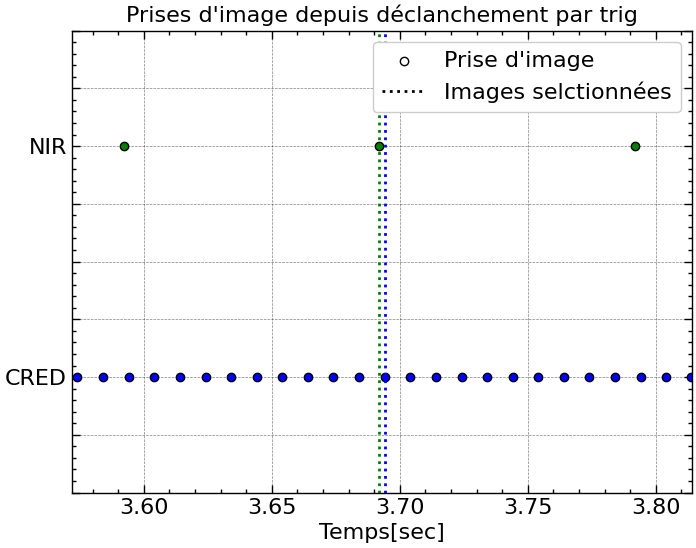

In [8]:
fig, ax = plt.subplots()

img_prise=[relative_time_CRED, relative_time_XIMEA]
extr=0.12

ax.vlines(
    img_prise,
    ymin=-0.5,
    ymax=1.5,
    color=['b', 'g'],
    linestyles='dotted'
    )
ax.scatter([0],[0], facecolor='white', edgecolor='black', label="Prise d'image")
ax.plot([0,0],[0,0], c='black', label="Images selctionnées", linestyle='dotted')

ax.scatter(local_time_CRED, np.ones(len(local_time_CRED))*0, facecolor='blue', edgecolor='black')
ax.scatter(local_time_XIMEA, np.ones(len(local_time_XIMEA))*1, facecolor='green', edgecolor='black')

ax.set_yticklabels(['', '', 'CRED','','','', 'NIR', ''])
ax.set_ylim(-0.5, 1.5)
ax.set_xlim(min(img_prise)-extr, max(img_prise)+extr)
ax.legend()
ax.set_xlabel('Temps[sec]')
plt.title(f"""Prises d'image depuis déclanchement par trig""")
plt.show()


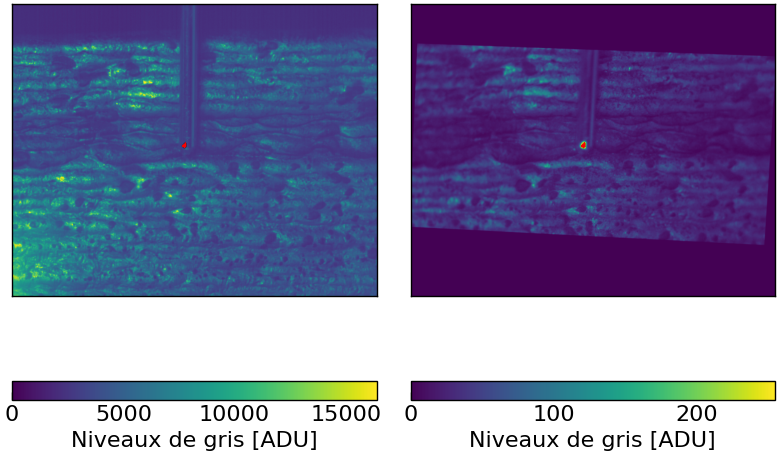

In [ ]:
im_CRED=np.load(
    f'{data_path}/CRED/{id_im_CRED[chosen_id_CRED]:06d}_{tim_python_CRED[chosen_id_CRED]:.3f}.npy'
)

im_XiQ_NIR=load_splitted_channels_nir(
    frame_path=f"{data_path}/XIQ/{id_im_NIR[chosen_id_XIMEA]:06d}_{tim_python_NIR[chosen_id_XIMEA]:.3f}.npy"
)


chanel=23
XIQ_raw=im_XiQ_NIR[chanel]
H_i=matrice_H[chanel]
XIQ_rescaled=cv2.warpPerspective(XIQ_raw, H_i, (COLUMNS_CRED, LINES_CRED))


# Array saved into: TherMIFASOL/resources/tables/pyrometer_relative_position/position_pyro_640x512.npy
pos_pyro=np.ones((XIQ_rescaled.shape[0], XIQ_rescaled.shape[1], 4), dtype=int)*0
pos_pyro[XIQ_rescaled==255,0]=255 
pos_pyro[XIQ_rescaled==255,3]=255

fig, axes = plt.subplots(1, 2)
cmp = 'viridis'

im1 = axes[0].imshow(im_CRED, cmap=cmp, vmin=0, vmax=2**14)
axes[0].imshow(pos_pyro)
#axes[0].set_title('CRED')
axes[0].axes.get_xaxis().set_ticks([])
axes[0].axes.get_yaxis().set_ticks([])
fig.colorbar(im1, ax=axes[0], orientation="horizontal", label="Niveaux de gris [ADU]")

im2 = axes[1].imshow(XIQ_rescaled, cmap=cmp, vmin=0, vmax=255)
axes[1].imshow(pos_pyro)
#axes[1].set_title(f'XiQ NIR')
axes[1].axes.get_xaxis().set_ticks([])
axes[1].axes.get_yaxis().set_ticks([])
fig.colorbar(im2, ax=axes[1], orientation="horizontal", label="Niveaux de gris [ADU]")

plt.tight_layout()
plt.show()
